In [1]:
!hostname

n21.clstr


In [16]:
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import xarray as xr
import geopandas as gpd
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
import seaborn as sns
from IPython.display import HTML
import regionmask

In [17]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [18]:
#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)


In [19]:
os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')

era5_4km = era5_4km.where(oceanmask != 17)
seasons=era5_4km['season']
lat=era5_4km['XLAT']
lon=era5_4km['XLONG']

In [20]:
era5_4km_1951_1980 = era5_4km.sel(season=slice('1951-1952', '1980-1981'))
era5_4km_1991_2020 = era5_4km.sel(season=slice('1991-1992', '2020-2021'))


monthlist = ['November','December','January','February','March']
monthnumberlist = [11,12,1,2,3]

In [21]:
def compute_ros_hours_normalized_monthly(data, month_numbers, month_labels):

    ros_hourly_totals = []
    n_pixels_per_month = []

    yearly_totals = {}
    yearly_n_pixels = {}
    yearly_normalized = {}

    for m, label in zip(month_numbers, month_labels):

        month_data = data.sel(month=m)

        # climatology (all years combined)
        ros_this_month = month_data.mean(dim="season")

        total = ros_this_month.sum().compute().item()
        ros_hourly_totals.append(total)

        n_pixels = (ros_this_month > 0).sum().compute().item()
        n_pixels_per_month.append(n_pixels)

        # yearly values (keep season dimension = years)
        yearly_totals[label] = (
            month_data.sum(dim=("south_north", "west_east"))
            .compute()
        )

        yearly_n_pixels[label] = (
            (month_data > 0)
            .sum(dim=("south_north", "west_east"))
            .compute()
        )

        yearly_normalized[label] = (
            yearly_totals[label] / yearly_n_pixels[label]
        )

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals, n_pixels_per_month)
    ]

    return (
        month_labels,
        ros_hourly_totals,
        n_pixels_per_month,
        ros_hours_normalized,
        yearly_totals,
        yearly_n_pixels,
        yearly_normalized,
    )

In [22]:
def borough_land_mask(shapefile,data):
    mask = regionmask.mask_geopandas(shapefile, data.XLONG, data.XLAT)
    data_masked = data.where(~np.isnan(mask))
    return data_masked

In [23]:
boundaries = {
    "bet": Bethel_boundary,
    "fai": FNSB_boundary,
    "anc": Mun_of_Anc_boundary,
    'statewide': None
}

periods = {
    "1951_1980": era5_4km_1951_1980,
    "1991_2020": era5_4km_1991_2020,
}

results = {}

for borough_name, boundary in boundaries.items():

    results[borough_name] = {}

    for period_name, ds in periods.items():
        if boundary is None:
            masked_ds = ds
        else:
            masked_ds = borough_land_mask(boundary, ds)
        (
                months,
                totals,
                n_pixels,
                normalized,
                yearly_totals,
                yearly_n_pixels,
                yearly_normalized,
        ) = compute_ros_hours_normalized_monthly(
            masked_ds["ros_tally"],
            monthnumberlist,
            monthlist,
        )

        results[borough_name][period_name] = {
            "months": months,
            "totals": totals,
            "n_pixels": n_pixels,
            "normalized": normalized,
            "yearly_totals": yearly_totals,
            "yearly_n_pixels": yearly_n_pixels,
            "yearly_normalized": yearly_normalized,
        }

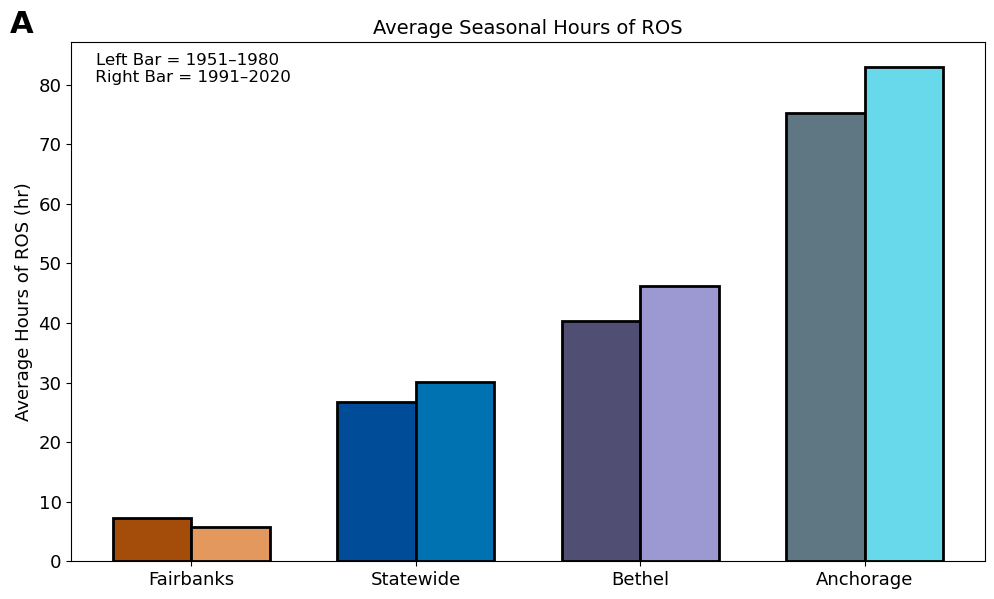

In [24]:


borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}
regions = ['fai', 'statewide', 'bet', 'anc']
labels = ['Fairbanks','Statewide','Bethel','Anchorage']
x = np.arange(len(labels))
width = 0.35  # width of each bar

old_ros = [
    np.sum(results[r]['1951_1980']['normalized'])
    for r in regions
]

new_ros = [
    np.sum(results[r]['1991_2020']['normalized'])
    for r in regions
]

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    x - width/2,
    old_ros,
    width,
    #yerr=unc_old,
    capsize=5,
    color=[borough_colors['Fairbanksold'],
           borough_colors['Statewideold'],
           borough_colors['Bethelold'],
           borough_colors['Anchorageold']],
    edgecolor='black',
    linewidth=2,
    label='1951-1980'
)

ax.bar(
    x + width/2,
    new_ros,
    width,
    #yerr=unc_new,
    capsize=5,
    color=[borough_colors['Fairbanksnew'],
           borough_colors['Statewidenew'],
           borough_colors['Bethelnew'],
           borough_colors['Anchoragenew']],
    edgecolor='black',
    linewidth=2,
    label='1991-2020'
)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=13)
ax.set_ylabel('Average Hours of ROS (hr)',fontsize=13)
ax.set_title('Average Seasonal Hours of ROS', fontsize=14)
ax.tick_params(axis='y', labelsize=13)
fig.text(0.19, 0.87, "Left Bar = 1951–1980 \n Right Bar = 1991–2020", ha='center', fontsize=12)
fig.text(0.01, 0.99, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
plt.tight_layout()
fig.patch.set_alpha(0.0)
plt.show()

Standard Error: 

In [26]:
#calculated the annual standard error 
months = ['November', 'December', 'January', 'February', 'March']

old_ros = []
new_ros = []
unc_old = []
unc_new = []
old_months = np.vstack([
        results[region]['1951_1980']['yearly_normalized'][m].values
        for m in months
    ]).T

old_seasonal = np.nansum(old_months, axis=1)

old_ros.append(np.nanmean(old_seasonal))

unc_old.append(
        np.nanstd(old_seasonal, ddof=1) /
        np.sqrt(np.sum(~np.isnan(old_seasonal))))
    
new_months = np.vstack([
        results[region]['1991_2020']['yearly_normalized'][m].values
        for m in months
    ]).T

new_seasonal = np.nansum(new_months, axis=1)
new_ros.append(np.nanmean(new_seasonal))

unc_new.append(
        np.nanstd(new_seasonal, ddof=1) /
        np.sqrt(np.sum(~np.isnan(new_seasonal)))
    )

NameError: name 'region' is not defined

ValueError: 'yerr' (shape: (0,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (4,))

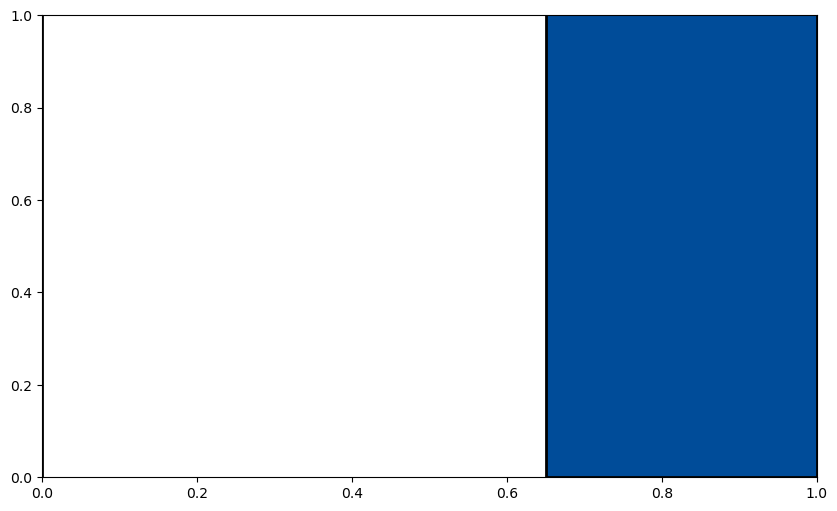

In [ ]:
borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}
regions = ['fai', 'statewide', 'bet', 'anc']
labels = ['Fairbanks','Statewide','Bethel','Anchorage']
x = np.arange(len(labels))
width = 0.35  # width of each bar

old_ros = [
    np.sum(results[r]['1951_1980']['normalized'])
    for r in regions
]

new_ros = [
    np.sum(results[r]['1991_2020']['normalized'])
    for r in regions
]

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    x - width/2,
    old_ros,
    width,
    yerr=unc_old,
    capsize=5,
    
#    hatch='//',
    
    color=[borough_colors['Fairbanksold'],
           borough_colors['Statewideold'],
           borough_colors['Bethelold'],
           borough_colors['Anchorageold']],
    edgecolor='black',
    linewidth=2,
    label='1951-1980'
)

ax.bar(
    x + width/2,
    new_ros,
    width,
    yerr=unc_new,
    capsize=5,
    color=[borough_colors['Fairbanksnew'],
           borough_colors['Statewidenew'],
           borough_colors['Bethelnew'],
           borough_colors['Anchoragenew']],
    edgecolor='black',
    linewidth=2,
    label='1991-2020'
)
#ax.legend(frameon=False, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=13)
ax.set_ylabel('Average Hours of ROS (hr)',fontsize=13)
ax.set_title('Average Seasonal Hours of ROS', fontsize=14)
ax.tick_params(axis='y', labelsize=13)
fig.text(0.025, 0.89,"Error bars = ±1 SE",transform=ax.transAxes,va='top',fontsize=11)
fig.text(0.19, 0.87, "Left Bar = 1951–1980 \n Right Bar = 1991–2020", ha='center', fontsize=12)
fig.text(0.01, 0.99, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
plt.tight_layout()
fig.patch.set_alpha(0.0)
plt.show()

In [ ]:
std_fai_seasonal_1950=np.nanstd([results['fai']['1951_1980']['yearly_normalized']['statewide'].values,
std_fai_seasonal_1950

3.710980119311043

In [ ]:

std_fai_seasonal_1950=np.nanstd([results['fai']['1951_1980']['yearly_normalized'][m] for m in months])
std_anc_seasonal_1950=np.nanstd([results['anc']['1951_1980']['yearly_normalized'][m] for m in months])
std_bet_seasonal_1950=np.nanstd([results['bet']['1951_1980']['yearly_normalized'][m] for m in months])
std_state_seasonal_1950=np.nanstd([results['statewide']['1951_1980']['yearly_normalized'][m] for m in months])

std_fai_seasonal_1991=np.nanstd([results['fai']['1991_2020']['yearly_normalized'][m] for m in months])
std_anc_seasonal_1991=np.nanstd([results['anc']['1991_2020']['yearly_normalized'][m] for m in months])
std_bet_seasonal_1991=np.nanstd([results['bet']['1991_2020']['yearly_normalized'][m] for m in months])
std_state_seasonal_1991=np.nanstd([results['statewide']['1991_2020']['yearly_normalized'][m] for m in months])

fai_1950_val = np.nanmean([results['fai']['1951_1980']['yearly_normalized'][m] for m in months])
anc_1950_val = np.nanmean([results['anc']['1951_1980']['yearly_normalized'][m] for m in months])
bet_1950_val = np.nanmean([results['bet']['1951_1980']['yearly_normalized'][m] for m in months])
state_1950_val = np.nanmean([results['statewide']['1951_1980']['yearly_normalized'][m] for m in months])

fai_1991_val = np.nanmean([results['fai']['1991_2020']['yearly_normalized'][m] for m in months])
anc_1991_val = np.nanmean([results['anc']['1991_2020']['yearly_normalized'][m] for m in months])
bet_1991_val = np.nanmean([results['bet']['1991_2020']['yearly_normalized'][m] for m in months])
state_1991_val = np.nanmean([results['statewide']['1991_2020']['yearly_normalized'][m] for m in months])


print(std_fai_seasonal_1950,std_anc_seasonal_1950,std_bet_seasonal_1950,std_state_seasonal_1950)
print(std_fai_seasonal_1991,std_anc_seasonal_1991,std_bet_seasonal_1991,std_state_seasonal_1991)
 
 
print(f"1950–1979 Fairbanks: {fai_1950_val:.2f} hrs ± {std_fai_seasonal_1950:.2f} hrs")
print(f"1950–1979 Anchorage: {anc_1950_val:.2f} hrs ± {std_anc_seasonal_1950:.2f} hrs")
print(f"1950–1979 Bethel: {bet_1950_val:.2f} hrs ± {std_bet_seasonal_1950:.2f} hrs")
print(f"1950–1979 Statewide: {state_1950_val:.2f} hrs ± {std_state_seasonal_1950:.2f} hrs")

print(f"1991–2020 Fairbanks: {fai_1991_val:.2f} hrs ± {std_fai_seasonal_1991:.2f} hrs")
print(f"1991–2020 Anchorage: {anc_1991_val:.2f} hrs ± {std_anc_seasonal_1991:.2f} hrs")
print(f"1991–2020 Bethel: {bet_1991_val:.2f} hrs ± {std_bet_seasonal_1991:.2f} hrs")
print(f"1991–2020 Statewide: {state_1991_val:.2f} hrs ± {std_state_seasonal_1991:.2f} hrs")

3.710980119311043 14.266379759640747 8.700052978140073 5.996945700513454
3.188736011128259 13.303906788145849 8.70414528635905 6.150905642448422
1950–1979 Fairbanks: 3.61 hrs ± 3.71 hrs
1950–1979 Anchorage: 22.36 hrs ± 14.27 hrs
1950–1979 Bethel: 9.75 hrs ± 8.70 hrs
1950–1979 Statewide: 15.41 hrs ± 6.00 hrs
1991–2020 Fairbanks: 2.81 hrs ± 3.19 hrs
1991–2020 Anchorage: 24.55 hrs ± 13.30 hrs
1991–2020 Bethel: 11.21 hrs ± 8.70 hrs
1991–2020 Statewide: 16.94 hrs ± 6.15 hrs


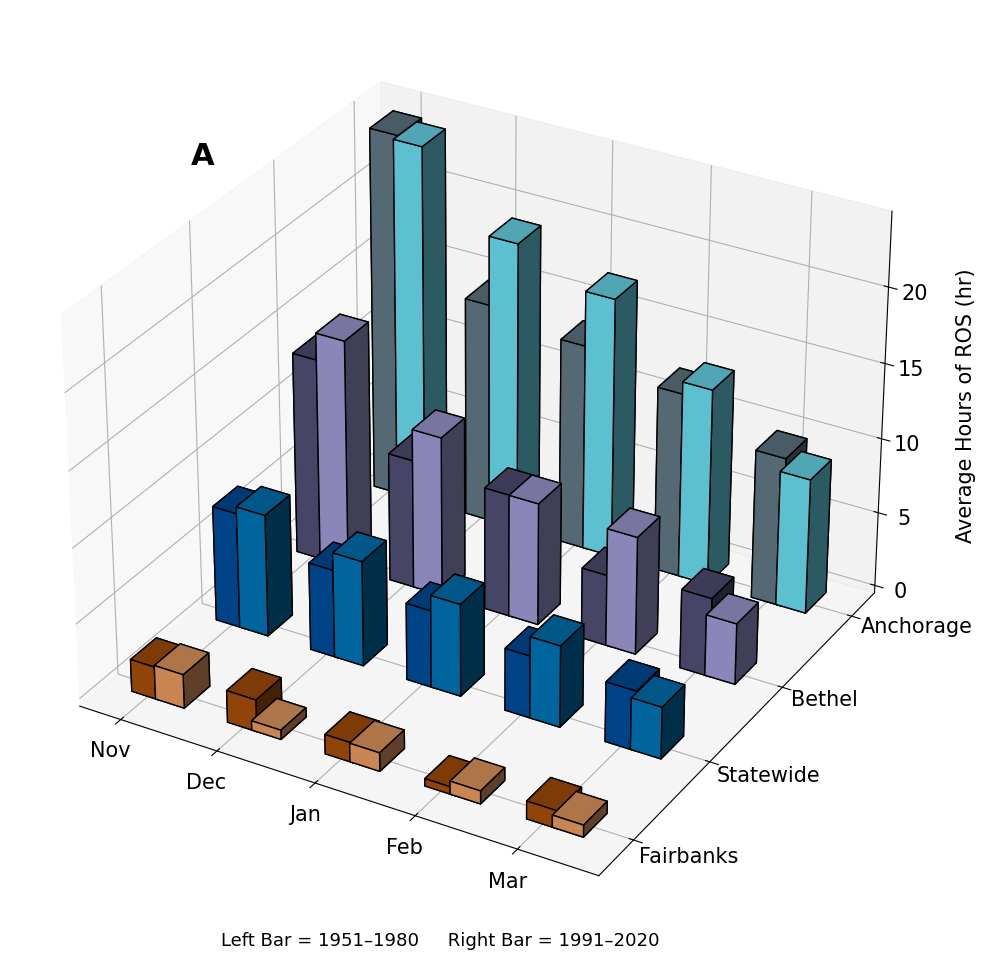

In [ ]:

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))

width = 0.3
depth = 0.3

fig = plt.figure(figsize=(25, 12))
ax = fig.add_subplot(111, projection='3d')

offsets = {
    "1951_1980": -0.1,
    "1991_2020": 0.15
}

region_info = {
    'fai': {
        'label': 'Fairbanks',
        'y': 0,
        'colors': {
            '1951_1980': borough_colors['Fairbanksold'],
            '1991_2020': borough_colors['Fairbanksnew']
        }
    },
    'statewide': {
        'label': 'Statewide',
        'y': 1,
        'colors': {
            '1951_1980': borough_colors['Statewideold'],
            '1991_2020': borough_colors['Statewidenew']
        }
    },
    'bet': {
        'label': 'Bethel',
        'y': 2,
        'colors': {
            '1951_1980': borough_colors['Bethelold'],
            '1991_2020': borough_colors['Bethelnew']
        }
    },
    'anc': {
        'label': 'Anchorage',
        'y': 3,
        'colors': {
            '1951_1980': borough_colors['Anchorageold'],
            '1991_2020': borough_colors['Anchoragenew']
        }
    }
}

for region, info in region_info.items():

    for period in ['1951_1980', '1991_2020']:

        values = results[region][period]['normalized']

        ax.bar3d(
            x + offsets[period],
            info['y'] * np.ones_like(x),
            np.zeros_like(x),
            width,
            depth,
            values,
            color=info['colors'][period],
            edgecolor='black'
        )

# Set axis labels
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=15)

yticks = [0.2, 1.2, 2.2, 3.2]
labels = ['Fairbanks','Statewide','Bethel','Anchorage']
ax.set_yticklabels([])
ax.set_yticks(yticks)

for y, label in zip(yticks, labels):
    ax.text(x[-1]+1.2 , y-.5, 2, label, fontsize=15, ha='left', va='center')

#ax.set_yticks([0.2,1.2,2.2,3.2])
#ax.set_yticklabels(['  Fairbanks','   Statewide','Bethel','    Anchorage'], fontsize=12)
#ax.set_zlabel('Average Hours of ROS (hr)', fontsize=12, rotation=90)
ax.tick_params(axis='z', labelsize=15)
fig.text(0.71, 0.55, 'Average Hours of ROS (hr)', rotation=90, fontsize=15, va='center', ha='center')
#ax.set_title('Average Hours of ROS by Borough\n(Normalized by Active Area)', y=0.99,fontsize=15)

#ax.set_title('Average Hours of ROS', fontsize=18, pad=20,y=.99)  
#fig.text(0.5, 0.84, 'Normalized by Active Area', ha='center', fontsize=14)

fig.text(.5, .1, "Left Bar = 1951–1980     Right Bar = 1991–2020", ha='center', fontsize=13)
fig.text(0.4, 0.77, 'A', fontsize=22, fontweight='bold', va='top', ha='left')
plt.show()

In [ ]:
#calculating the monthly standard error: 
results['fai']['1991_2020']['yearly_totals']['November']

<xarray.DataArray 'ros_tally' (season: 30)> Size: 240B
array([4.3900e+02, 1.0500e+03, 2.7520e+03, 3.2600e+02, 6.3200e+02,
       0.0000e+00, 1.2900e+02, 2.3000e+01, 4.7000e+01, 4.0750e+03,
       0.0000e+00, 9.3840e+03, 1.0217e+04, 5.7400e+02, 3.7000e+01,
       0.0000e+00, 1.4850e+03, 0.0000e+00, 0.0000e+00, 2.7727e+04,
       0.0000e+00, 0.0000e+00, 7.2640e+03, 1.5560e+03, 3.7630e+03,
       2.9300e+02, 0.0000e+00, 3.0550e+03, 4.1630e+03, 1.3770e+03])
Coordinates:
  * season      (season) <U9 1kB '1991-1992' '1992-1993' ... '2020-2021'
    month       int64 8B 11
    month_name  <U3 12B 'Nov'

In [77]:
np.nanmean(results['fai']['1991_2020']['yearly_normalized']['December'])

1.8527583764800726

In [78]:
np.nanmean(results['fai']['1951_1980']['yearly_normalized']['December'])

5.5603071034607945

In [ ]:
def compute_se(data_array):
    vals = data_array.values
    return np.nanstd(vals, ddof=1) / np.sqrt(np.sum(~np.isnan(vals)))

In [71]:
se_nov = compute_se(results['fai']['1991_2020']['yearly_totals']['November'])

In [27]:
results = {}

for borough_name, boundary in boundaries.items():

    results[borough_name] = {}

    for period_name, ds in periods.items():

        if boundary is None:
            masked_ds = ds
        else:
            masked_ds = borough_land_mask(boundary, ds)

        (
            months,
            totals,
            n_pixels,
            normalized,
            yearly_totals,
            yearly_n_pixels,
            yearly_normalized,
        ) = compute_ros_hours_normalized_monthly(
            masked_ds["ros_tally"],
            monthnumberlist,
            monthlist,
        )

        # ----------------------------
        # COMPUTE MONTHLY MEAN + SE
        # ----------------------------
        monthly_stats = {}

        for m in monthlist:

            da = yearly_normalized[m]   # (season dimension)

            da = da.compute()

            mean = float(da.mean(dim="season"))
            se = float(da.std(dim="season", ddof=1) / np.sqrt(da.sizes["season"]))

            monthly_stats[m] = {
                "mean": mean,
                "se": se
            }

        results[borough_name][period_name] = monthly_stats

In [28]:
for b in results:
    for p in results[b]:
        print(f"\n{b} {p}")

        for m in monthlist:
            r = results[b][p][m]
            print(f"{m}: {r['mean']:.2f} ± {r['se']:.2f}")


bet 1951_1980
November: 15.02 ± 1.77
December: 10.18 ± 1.71
January: 9.98 ± 1.75
February: 6.30 ± 0.83
March: 7.16 ± 1.26

bet 1991_2020
November: 17.23 ± 1.94
December: 12.65 ± 1.50
January: 10.17 ± 1.14
February: 9.60 ± 1.59
March: 6.23 ± 0.93

fai 1951_1980
November: 3.86 ± 0.73
December: 5.56 ± 0.91
January: 3.22 ± 0.59
February: 2.23 ± 0.46
March: 3.21 ± 0.57

fai 1991_2020
November: 4.56 ± 0.99
December: 1.85 ± 0.17
January: 2.89 ± 0.43
February: 2.39 ± 0.46
March: 2.43 ± 0.50

anc 1951_1980
November: 30.37 ± 3.20
December: 22.06 ± 2.47
January: 20.52 ± 2.70
February: 20.71 ± 2.32
March: 18.35 ± 1.82

anc 1991_2020
November: 29.46 ± 3.01
December: 27.93 ± 2.21
January: 25.58 ± 2.41
February: 21.96 ± 1.98
March: 17.82 ± 1.95

statewide 1951_1980
November: 19.65 ± 0.92
December: 16.93 ± 1.17
January: 14.87 ± 1.16
February: 12.69 ± 0.92
March: 12.94 ± 0.80

statewide 1991_2020
November: 20.05 ± 1.13
December: 19.62 ± 1.02
January: 17.09 ± 1.08
February: 15.00 ± 0.94
March: 12.94 ± 